<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Carbon_Plated_vs_Training_Footwear_Running.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Biomechanical and Neurological Basis of Human Movement - Jared Ozarzak - Lab 3**

In [ ]:
import urllib.request
import zipfile
import os

# --------------------------------------------------
# STUDENT INPUT (edit only this line; case-sensitive)
# --------------------------------------------------
GROUP = "lannister"   # e.g., "targaryen", "stark", "lannister", "martell", "greyjoy"

# --------------------------------------------------
# Configuration (do NOT edit below)
# These lines create a directory for this lab in your
# Colab working directory.
# --------------------------------------------------
zip_dir = "kin6015/lab3"
os.makedirs(zip_dir, exist_ok=True)

zip_filename = f"spring2026_lab3_{GROUP}.zip"

url = (
    "https://raw.githubusercontent.com/"
    "plnu-biomechanics/kin6015/main/"
    f"labs/{zip_filename}"
)

zip_path = os.path.join(zip_dir, zip_filename)

# --------------------------------------------------
# Download zip file
# --------------------------------------------------
urllib.request.urlretrieve(url, zip_path)

# --------------------------------------------------
# Extract contents from the zipped file
# --------------------------------------------------
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(zip_dir)

print("Extracted files in lab directory:")
print(os.listdir(zip_dir))


Extracted files in lab directory:
['Lannister_CFP_05.txt', 'Martell_TRN_03.txt', 'spring2026_lab3_martell.zip', 'Lannister_CFP_02.txt', 'Lannister_TRN_05.txt', 'Lannister_CFP_01.txt', 'Lannister_CFP_03.txt', 'Martell_CFP_04.txt', 'Martell_CFP_03.txt', 'Lannister_TRN_04.txt', 'Martell_TRN_02.txt', 'Martell_TRN_01.txt', 'Lannister_TRN_02.txt', 'Martell_CFP_02.txt', 'Martell_CFP_05.txt', 'Lannister_CFP_04.txt', 'Lannister_TRN_03.txt', 'Martell_TRN_04.txt', 'spring2026_lab3_lannister.zip', 'Lannister_TRN_01.txt', 'Martell_TRN_05.txt', 'Martell_CFP_01.txt']


In [ ]:
import pandas as pd
import os
import re # Import the regular expression module

def parse_txt_file(filepath):
  """Reads a text file, extracts variable names and time-series data, identifies the condition,
  and returns a pandas DataFrame.

  Args:
    filepath (str): The full path to the text file.

  Returns:
    pd.DataFrame: A DataFrame containing the extracted data, condition, and filename.
  """
  with open(filepath, 'r') as file:
    lines = file.readlines()

  # Check if file has enough lines for the expected structure
  if len(lines) < 6: # Need at least 6 lines (5 header, 1 data)
      raise ValueError(f"File {os.path.basename(filepath)} has too few lines to parse correctly.")

  # Extract variable names from the 2nd line (index 1), using tab as delimiter
  variable_names = lines[1].strip().split('\t')

  # Read time-series data starting from the 6th line (index 5), using tab as delimiter
  data_lines = [line.strip().split('\t') for line in lines[5:] if line.strip()]

  # Ensure data_lines is not empty before checking lengths
  if not data_lines:
      raise ValueError(f"No data found in file {os.path.basename(filepath)} after header.")

  # Dynamically add 'Frame' if data rows have one more column than variable names
  if len(data_lines[0]) == len(variable_names) + 1:
      variable_names.insert(0, 'Frame')

  # Ensure variable names and data lines match in length AFTER potential adjustment
  if len(variable_names) != len(data_lines[0]):
      raise ValueError(f"Column name count ({len(variable_names)}) does not match data column count ({len(data_lines[0])}) in file {os.path.basename(filepath)}.")

  # Create DataFrame
  df = pd.DataFrame(data_lines, columns=variable_names)

  # Remove '_MEAN' or '_Mean' suffixes from column names
  new_columns = []
  for col in df.columns:
      new_col = re.sub(r'_MEAN$|_Mean$', '', col)
      new_columns.append(new_col)
  df.columns = new_columns

  # Rename 'MAX_R_GRF_MEAN' to 'Vertical GRF' if it exists
  if 'MAX_R_GRF' in df.columns:
    df = df.rename(columns={'MAX_R_GRF': 'Vertical GRF'})

  # Rename 'KNEE_ANG@FS' to 'Knee Flexion at FC' if it exists
  if 'KNEE_ANG@FS' in df.columns:
    df = df.rename(columns={'KNEE_ANG@FS': 'Knee Flexion at FC'})

  # Rename 'Right Ankle Angles_MIN' to 'Peak Plantarflexion' if it exists
  if 'Right Ankle Angles_MIN' in df.columns:
    df = df.rename(columns={'Right Ankle Angles_MIN': 'Peak Plantarflexion'})


  # Convert numeric columns to appropriate data types
  for col in df.columns:
    try:
      df[col] = pd.to_numeric(df[col])
    except ValueError:
      pass # Keep as string if not numeric

  # Determine 'condition' from filename
  filename = os.path.basename(filepath)
  if 'CFP' in filename:
    condition = 'carbonfiber'
  elif 'TRN' in filename:
    condition = 'training'
  else:
    condition = 'unknown'

  # Add 'condition' column
  df['condition'] = condition

  # Add 'filename' column
  df['filename'] = filename

  return df

print("Updated function 'parse_txt_file' to handle tab-delimited data, correct line indexing, dynamic 'Frame' column, case-sensitive condition check, import 're' module, rename 'Right Ankle Angles' column, and remove '_MEAN'/'_Mean' suffixes.")


# 1. Get the list of .txt files from the working directory
zip_dir = "kin6015/lab3"
all_files = os.listdir(zip_dir)
txt_files = [f for f in all_files if f.endswith('.txt')]

# 2. Initialize an empty list to store DataFrames
all_dataframes = []

# 3. Iterate through each .txt file and apply the parse_txt_file function
for filename in txt_files:
    filepath = os.path.join(zip_dir, filename)
    try:
        df = parse_txt_file(filepath)
        all_dataframes.append(df)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

# 4. Concatenate all DataFrames into a single combined_intermediate_df
if all_dataframes:
    combined_intermediate_df = pd.concat(all_dataframes, ignore_index=True)
    print("Combined_intermediate_df created successfully.")
else:
    combined_intermediate_df = pd.DataFrame()
    print("No dataframes to concatenate, combined_intermediate_df is empty.")

# 5. Create timeseries_df
timeseries_df = combined_intermediate_df[
    [
        'Frame',
        'Right Knee Angles',
        'Right Ankle Angles',
        'Right Foot Contact Angle',
        'condition',
        'filename'
        ]
    ]

# 6. Create discretes_df
discretes_df = combined_intermediate_df[combined_intermediate_df['Frame'] == 1][
    [
        'filename',
        'condition',
        'Stride_Length',
        'Stride_Width',
        'Vertical GRF',
        'Knee Flexion at FC',
        'Peak Plantarflexion'
        ]
    ]

# 7. Display the head of timeseries_df
print("\nHead of timeseries_df:")
print(timeseries_df.head())

# 8. Display the head of discretes_df
print("\nHead of discretes_df:")
print(discretes_df.head())

Updated function 'parse_txt_file' to handle tab-delimited data, correct line indexing, dynamic 'Frame' column, case-sensitive condition check, import 're' module, rename 'Right Ankle Angles' column, and remove '_MEAN'/'_Mean' suffixes.
Combined_intermediate_df created successfully.

Head of timeseries_df:
   Frame  Right Knee Angles  Right Ankle Angles  Right Foot Contact Angle  \
0      1           57.75609            16.29205                 -17.78431   
1      2           57.23649            16.48208                 -18.11537   
2      3           56.64273            17.04269                 -18.37496   
3      4           55.98168            17.96585                 -18.60909   
4      5           55.26723            19.19041                 -18.84190   

     condition              filename  
0  carbonfiber  Lannister_CFP_05.txt  
1  carbonfiber  Lannister_CFP_05.txt  
2  carbonfiber  Lannister_CFP_05.txt  
3  carbonfiber  Lannister_CFP_05.txt  
4  carbonfiber  Lannister_CFP_05.tx

In [ ]:
!pip install spm1d
print("spm1d library installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 9.9 MB/s eta 0:00:00
spm1d library installed.


In [ ]:
import numpy as np

# ================
# DATA WRANGLING
# =================

# This code chunk wrangles time-series data into respective arrays for SPM analysis

# Recreate timeseries_df with .copy() to avoid SettingWithCopyWarning
timeseries_df = combined_intermediate_df[
    [
        'Frame',
        'Right Knee Angles',
        'Right Ankle Angles',
        'Right Foot Contact Angle',
        'condition',
        'filename'
        ]
    ].copy()

# Add 'trial_id' column by cleaning the 'filename'
timeseries_df['trial_id'] = timeseries_df['filename'].str.replace('_carbonfiber', '', regex=False)
timeseries_df['trial_id'] = timeseries_df['trial_id'].str.replace('_training', '', regex=False)
timeseries_df['trial_id'] = timeseries_df['trial_id'].str.replace('.txt', '', regex=False)

print("Head of timeseries_df with new 'trial_id' column:")
display(timeseries_df)

print("\nUnique trial IDs:")
print(timeseries_df.head())

print("\nUnique trial IDs:")
print(timeseries_df['trial_id'].unique())

# export CSV file for inspection (comment if not needed)
# timeseries_df.to_csv('timeseries_data.csv', index=False)
# print("timeseries_df exported to 'timeseries_data.csv'")

# Filter for both conditions
carbonfiber_df = timeseries_df[timeseries_df['condition'] == 'carbonfiber']
training_df = timeseries_df[timeseries_df['condition'] == 'training']

# Prepare data for Knee Flexion (carbonfiber)
kneeflexion_carbonfiber_data = carbonfiber_df.pivot(index='trial_id', columns='Frame', values='Right Knee Angles').values

# Prepare data for Knee Flexion (training)
kneeflexion_training_data = training_df.pivot(index='trial_id', columns='Frame', values='Right Knee Angles').values

# Prepare data for Ankle PF (carbonfiber)
ankleplantar_carbonfiber_data = carbonfiber_df.pivot(index='trial_id', columns='Frame', values='Right Ankle Angles').values

# Prepare data for Ankle PF (training)
ankleplantar_training_data = training_df.pivot(index='trial_id', columns='Frame', values='Right Ankle Angles').values

# Prepare data for Foot Pronation (carbonfiber)
footpronation_carbonfiber_data = carbonfiber_df.pivot(index='trial_id', columns='Frame', values='Right Foot Contact Angle').values

# Prepare data for Foot Pronation (training)
footpronation_training_data = training_df.pivot(index='trial_id', columns='Frame', values='Right Foot Contact Angle').values

print("Shape of Knee Flexion (carbonfiber) data:", kneeflexion_carbonfiber_data.shape)
print("Shape of Knee Flexion (training) data:", kneeflexion_training_data.shape)
print("Shape of Ankle PF (carbonfiber) data:", ankleplantar_carbonfiber_data.shape)
print("Shape of Ankle PF (training) data:", ankleplantar_training_data.shape)
print("Shape of Pronation (carbonfiber) data:", footpronation_carbonfiber_data.shape)
print("Shape of Prontation (training) data:", footpronation_training_data.shape)

Head of timeseries_df with new 'trial_id' column:


,Frame,Right Knee Angles,Right Ankle Angles,Right Foot Contact Angle,condition,filename,trial_id
0,1,57.75609,16.29205,-17.78431,carbonfiber,Lannister_CFP_05.txt,Lannister_CFP_05
1,2,57.23649,16.48208,-18.11537,carbonfiber,Lannister_CFP_05.txt,Lannister_CFP_05
2,3,56.64273,17.04269,-18.37496,carbonfiber,Lannister_CFP_05.txt,Lannister_CFP_05
3,4,55.98168,17.96585,-18.60909,carbonfiber,Lannister_CFP_05.txt,Lannister_CFP_05
4,5,55.26723,19.19041,-18.84190,carbonfiber,Lannister_CFP_05.txt,Lannister_CFP_05
...,...,...,...,...,...,...,...
2015,97,5.67186,11.28511,-8.83225,carbonfiber,Martell_CFP_01.txt,Martell_CFP_01
2016,98,6.64760,10.97249,-9.69765,carbonfiber,Martell_CFP_01.txt,Martell_CFP_01
2017,99,7.87264,10.21233,-11.08670,carbonfiber,Martell_CFP_01.txt,Martell_CFP_01
2018,100,9.39979,9.07881,-12.81538,carbonfiber,Martell_CFP_01.txt,Martell_CFP_01



Unique trial IDs:
   Frame  Right Knee Angles  Right Ankle Angles  Right Foot Contact Angle  \
0      1           57.75609            16.29205                 -17.78431   
1      2           57.23649            16.48208                 -18.11537   
2      3           56.64273            17.04269                 -18.37496   
3      4           55.98168            17.96585                 -18.60909   
4      5           55.26723            19.19041                 -18.84190   

     condition              filename          trial_id  
0  carbonfiber  Lannister_CFP_05.txt  Lannister_CFP_05  
1  carbonfiber  Lannister_CFP_05.txt  Lannister_CFP_05  
2  carbonfiber  Lannister_CFP_05.txt  Lannister_CFP_05  
3  carbonfiber  Lannister_CFP_05.txt  Lannister_CFP_05  
4  carbonfiber  Lannister_CFP_05.txt  Lannister_CFP_05  

Unique trial IDs:
['Lannister_CFP_05' 'Martell_TRN_03' 'Lannister_CFP_02' 'Lannister_TRN_05'
 'Lannister_CFP_01' 'Lannister_CFP_03' 'Martell_CFP_04' 'Martell_CFP_03'
 'Lannist

/tmp/ipython-input-420232503.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)
/tmp/ipython-input-420232503.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)
/tmp/ipython-input-420232503.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)


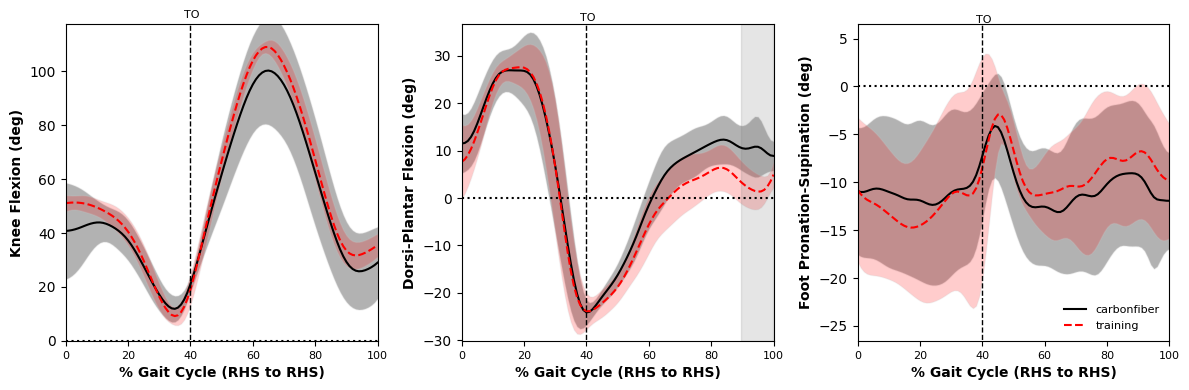

In [ ]:
import spm1d
import numpy as np
import matplotlib.pyplot as pyplot

total_frames = 101
num_ticks = 6  # Number of ticks (0%, 10%, ..., 100%)

# Define a function to create each plot
def plot_spm(ax, Y1, Y2, label_Y1, label_Y2, x_label, y_label, y_limits, units, color_Y1, color_Y2, show_legend):
    spm1d.plot.plot_mean_sd(Y1, label=label_Y1, linecolor=color_Y1, facecolor=color_Y1, ax=ax, lw=1.5, alpha=0.3)
    spm1d.plot.plot_mean_sd(Y2, label=label_Y2, linecolor=color_Y2, facecolor=color_Y2, linestyle='--', lw=1.5, alpha=0.20, ax=ax)
    ax.axhline(y=0, color='k', linestyle=':')

    # Conduct t-test:
    alpha      = 0.05
    t          = spm1d.stats.ttest2(YB, YA)
    ti         = t.inference(alpha, two_tailed=True, interp=True)

    # Highlight suprathreshold regions
    for cluster in ti.clusters:
        start, end = cluster.endpoints
        ax.axvspan(start, end, ymin=0, ymax=1.0, color='grey', alpha=0.20)

    # Generate plots
    percentages = np.linspace(0, 100, num_ticks)  # 0%, 10%, ..., 100%
    x_ticks = (percentages / 100) * total_frames  # Normalize frame numbers
    ypos = y_limits[1] + y_limits[1]*.02          # event labels
    ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)
    ax.vlines(x=40, ymin=y_limits[0]-100, ymax=y_limits[1]+100, color='k', linestyle='--', lw=1)
    ax.text(38, ypos, 'TO', fontsize=8)
    ax.set_xlabel(x_label, fontsize=10, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=10, fontweight='bold') if y_label else ax.set_ylabel("")

    ax.set_ylim(y_limits)

    if show_legend:
      ax.legend(fontsize=8, loc='lower right', frameon=False)

# Combine both SPM plots (no SPM{t} fields)
pyplot.figure( figsize=(12, 4) ) # Adjusted figsize for 3 plots horizontally

# =============================================================================
# KNEE FLEXION
# =============================================================================

# Replace x and y axes and filename label
xlabel = "% Gait Cycle (RHS to RHS)"
ylabel="Knee Flexion"
units = "deg"

# YA (black)
YA            = kneeflexion_carbonfiber_data

# YB (red)
YB            = kneeflexion_training_data

# Calculate shared y-axis limits
min_val = min(YA.min(), YB.min())
if min_val > 0:
    min_val = 0
max_val = max(YA.max(), YB.max())
y_limits = [min_val, max_val]

# Subplot 1
ax1 = pyplot.subplot(1, 3, 1) # Changed to 1 row, 3 columns, position 1
plot_spm(
    ax1, YA, YB,
    label_Y1="carbonfiber",
    label_Y2="training",
    x_label = xlabel,
    y_label=f'{ylabel} ({units})',
    y_limits=y_limits,
    units=units,
    color_Y1='k',
    color_Y2='r',
    show_legend=False
)


# =============================================================================
# ANKLE PF
# =============================================================================

# Replace x and y axes and filename label
# xlabel = "% Gait Cycle (RHS to RHS)"
ylabel="Dorsi-Plantar Flexion"
units = "deg"

# YA (black)
YA            = ankleplantar_carbonfiber_data

# YB (red)
YB            = ankleplantar_training_data

# Calculate shared y-axis limits
min_val = min(YA.min(), YB.min())
if min_val > 0:
    min_val = 0
max_val = max(YA.max(), YB.max())
y_limits = [min_val, max_val]

# Subplot 2
ax2 = pyplot.subplot(1, 3, 2) # Changed to 1 row, 3 columns, position 2
plot_spm(
    ax2, YA, YB,
    label_Y1="carbonfiber",
    label_Y2="training",
    x_label = xlabel,
    y_label=f'{ylabel} ({units})',
    y_limits=y_limits,
    units=units,
    color_Y1='k',
    color_Y2='r',
    show_legend=False
)

# =============================================================================
# FOOT PRONATION
# =============================================================================

# Replace x and y axes and filename label
# xlabel = "% Gait Cycle (RHS to RHS)"
ylabel="Foot Pronation-Supination"
units = "deg"

# YA (black)
YA            = footpronation_carbonfiber_data

# YB (red)
YB            = footpronation_training_data

# Calculate shared y-axis limits
min_val = min(YA.min(), YB.min())
if min_val > 0:
    min_val = 0
max_val = max(YA.max(), YB.max())
y_limits = [min_val, max_val]

# Subplot 3
ax3 = pyplot.subplot(1, 3, 3) # Changed to 1 row, 3 columns, position 3
plot_spm(
    ax3, YA, YB,
    label_Y1="carbonfiber",
    label_Y2="training",
    x_label = xlabel,
    y_label=f'{ylabel} ({units})',
    y_limits=y_limits,
    units=units,
    color_Y1='k',
    color_Y2='r',
    show_legend=True
)

### plot SPM results:
pyplot.tight_layout()
pyplot.show()

In [ ]:
import pandas as pd
from scipy.stats import ttest_rel

# 1. Create a copy of discretes_df
discretes_for_analysis_df = discretes_df.copy()

# 2. Extract a unique subject identifier (the numerical part of the filename) from the 'filename' column
# Assuming filenames are like 'GROUP_CONDITION_SUBJECTID.txt' (e.g., Martell_TRN_04.txt -> 04)
discretes_for_analysis_df['trial_id'] = discretes_for_analysis_df['filename'].str.extract(r'_(\d+)\.txt$')[0]

# Define the desired column order
# This will effectively drop 'filename' and place 'trial_id' after 'condition'
final_columns = ['condition', 'trial_id'] + [col for col in discretes_for_analysis_df.columns if col not in ['condition', 'trial_id', 'filename']]
discretes_for_analysis_df = discretes_for_analysis_df[final_columns]

# Sort the DataFrame by 'condition' to ensure 'carbonfiber' comes before 'training'
# This uses 'carbonfiber' and 'training' as categories with a specific order
discretes_for_analysis_df['condition'] = pd.Categorical(
    discretes_for_analysis_df['condition'],
    categories=['carbonfiber', 'training'],
    ordered=True
)
discretes_for_analysis_df = discretes_for_analysis_df.sort_values(by=['condition', 'trial_id']).reset_index(drop=True)

# 3. Display the head of the discretes_for_analysis_df to verify the new 'trial_id' column and sorting
print("Head of discretes_for_analysis_df with new 'trial_id' column and sorted conditions:")
print(discretes_for_analysis_df.head())

# 4. Define a list of the variables for which summary statistics need to be calculated
summary_variables = [
  'Stride_Length',
  'Stride_Width',
  'Vertical GRF',
  'Knee Flexion at FC',
  'Peak Plantarflexion'
]

# 5. Group the discretes_for_analysis_df DataFrame by the 'condition' column
# 6. For each of the specified variables, calculate the mean, standard deviation, and count for each 'condition' group
summary_statistics = discretes_for_analysis_df.groupby('condition')[summary_variables].agg(
    ['mean', 'std', 'count']
)

# 7. Store these summary statistics in a new DataFrame (already done by the agg function)
# The result is automatically a DataFrame with a multi-level index/columns which is well-organized.

# 8. Display the resulting summary statistics DataFrame
print("Descriptive Statistics grouped by Condition:")
print(summary_statistics)

# 9. Define a list of the variables for which paired t-tests need to be performed
pair_ttest_variables = [
  'Stride_Length',
  'Stride_Width',
  'Vertical GRF',
  'Knee Flexion at FC',
  'Peak Plantarflexion'
]

# 10. Initialize a dictionary to store the t-test results
t_test_results = {}

# 11. For each variable in the defined list:
for var in pair_ttest_variables:
    # a. Filter discretes_for_analysis_df to get data for the 'carbonfiber' condition.
    carbonfiber_data = discretes_for_analysis_df[discretes_for_analysis_df['condition'] == 'carbonfiber'][['trial_id', var]]

    # b. Filter discretes_for_analysis_df to get data for the 'training' condition.
    training_data = discretes_for_analysis_df[discretes_for_analysis_df['condition'] == 'training'][['trial_id', var]]

    # c. Ensure that both filtered DataFrames contain the same 'trial_id's and are sorted by 'trial_id'
    # to guarantee correct pairing.
    merged_data = pd.merge(carbonfiber_data, training_data, on='trial_id', suffixes=('_carbonfiber', '_training'))

    # Drop rows where either carbonfiber or training data is NaN for the current variable
    merged_data = merged_data.dropna(subset=[var + '_carbonfiber', var + '_training'])

    # Extract the values for the current variable from both filtered DataFrames.
    data_carbonfiber = merged_data[var + '_carbonfiber']
    data_training = merged_data[var + '_training']

    # d. Perform a paired t-test using ttest_rel on these two sets of values.
    # Check if there are enough samples to perform the t-test
    if len(data_carbonfiber) >= 2 and len(data_training) >= 2:
        t_statistic, p_value = ttest_rel(data_carbonfiber, data_training)
    else:
        t_statistic, p_value = float('nan'), float('nan') # Set to NaN if not enough samples

    # e. Store the resulting t-statistic and p-value.
    t_test_results[var] = {'t_statistic': t_statistic, 'p_value': p_value}

# 12. Print or display the collected t-test results for each variable.
print("\nPaired t-test results (carbonfiber vs. training):")
for var, results in t_test_results.items():
    print(f"Variable: {var}")
    print(f"  t-statistic: {results['t_statistic']:.3f}")
    print(f"  p-value: {results['p_value']:.3f}")
    print("-----------------------------------------")
# 13. Initialize an empty list to store the data for the APA-style table
apa_table_data = []

# 14. Iterate through each variable in the pair_ttest_variables list
for var in pair_ttest_variables:
    # 3. For each variable, extract the mean and standard deviation for 'carbonfiber' and 'training' conditions
    #    from the summary_statistics DataFrame.
    mean_carbonfiber = summary_statistics.loc['carbonfiber', (var, 'mean')]
    std_carbonfiber = summary_statistics.loc['carbonfiber', (var, 'std')]
    mean_training = summary_statistics.loc['training', (var, 'mean')]
    std_training = summary_statistics.loc['training', (var, 'std')]

    # 4. Extract the t-statistic and p-value for the current variable from the t_test_results dictionary.
    t_stat = t_test_results[var]['t_statistic']
    p_val = t_test_results[var]['p_value']

    # 5. Create a dictionary for the current row with appropriate keys and formatted numerical values.
    row = {
        'Variable': var,
        'M \u00b1 SD (carbonfiber)': f"{mean_carbonfiber:.2f} \u00b1 {std_carbonfiber:.2f}",
         # 'SD (carbonfiber)': f"{std_carbonfiber:.2f}",
        'M \u00b1 SD (training)': f"{mean_training:.2f} \u00b1 {std_training:.2f}",
         # 'SD (training)': f"{std_training:.2f}",
         # 't': f"{t_stat:.3f}",
        'p': f"{p_val:.3f}"
    }

    # Append this row dictionary to the list.
    apa_table_data.append(row)

# 15. Create a pandas DataFrame from the list of rows.
apa_table_df = pd.DataFrame(apa_table_data)

print("APA-Style Summary and Paired t-test Results Table:")
print(apa_table_df.to_string(index=False))

Head of discretes_for_analysis_df with new 'trial_id' column and sorted conditions:
     condition trial_id  Stride_Length  Stride_Width  Vertical GRF  \
0  carbonfiber       01        2.35785       0.14952    1035.92249   
1  carbonfiber       01        2.13158       0.16634    1653.08606   
2  carbonfiber       02        2.37244       0.15158    1202.57788   
3  carbonfiber       02        2.10774       0.14994    1672.34546   
4  carbonfiber       03        2.32366       0.15012    1128.47485   

   Knee Flexion at FC  Peak Plantarflexion  
0            51.39185            -24.14258  
1            16.55101            -29.10514  
2            45.54979            -22.91671  
3            17.44683            -28.28432  
4            47.60735            -22.63820  
Descriptive Statistics grouped by Condition:
            Stride_Length                 Stride_Width                  \
                     mean       std count         mean       std count   
condition                       

/tmp/ipython-input-439509026.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_statistics = discretes_for_analysis_df.groupby('condition')[summary_variables].agg(


In [ ]:

import os

# Construct the full file path for the CSV file
output_filepath = os.path.join(zip_dir, f"{GROUP}_discretes_for_analysis_lab3.csv")

# Export the DataFrame to CSV
discretes_for_analysis_df.to_csv(output_filepath, index=False)

# Print a confirmation message
print(f"'discretes_for_analysis_df' exported to '{output_filepath}'")

# Construct the full file path for the CSV file
output_filepath = os.path.join(zip_dir, f"{GROUP}_summary_stats_lab3.csv")

# Export the APA formatted summary DataFrame to CSV
apa_table_df.to_csv(output_filepath, index=False)

# Print a confirmation message
print(f"'summary_statistics' exported to '{output_filepath}'")

'discretes_for_analysis_df' exported to 'kin6015/lab3/lannister_discretes_for_analysis_lab3.csv'
'summary_statistics' exported to 'kin6015/lab3/lannister_summary_stats_lab3.csv'
